## Imports

In [ ]:
from   pathlib import Path
import matplotlib.pyplot as plt
import pickle
import torch
# import mlflow

from neuralhydrology.evaluation     import metrics
from neuralhydrology.nh_run         import start_run, eval_run
from neuralhydrology.datasetzoo     import register_dataset
from neuralhydrology.utils.config   import Config

from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)

# Custom functions plot_training_curves
from custom.functions.Plot import plot_training_curves, plot_validation_metrics
from custom.functions.Plot import plot_mape_horizon, plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series
from custom.functions.utils_fla import parse_neuralhydrology_log
from custom.functions.utils_fla import info_results, mape_array, dict_without_xr_key


---

## Parameters of the run

In [ ]:
config_file = Path("t0.yml")
cfg = Config(config_file)

# Here write the name of the run if renamed run or if you want to plot the specified run, otherwise will take the run_dir created during training
# example: "expName_TimeStamp" 
runFile = None 

# list of basins, DB -> name of the basin.txt where the name of the csv is indicated
basin = "massa_2"

# Whether you want to run a training, put false to plot your specific run folder for example
TRAIN, Evaluation_TEST = True, True


In [ ]:

if TRAIN:
    print("--- Starting the training of the model ---")
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        print("Using GPU")
        run_dir = start_run(config_file=Path(config_file))
    else:
        print("Using CPU")
        run_dir = start_run(config_file=Path(config_file), gpu=-1)
    print("==================================")
    print("  Training ended successfully !   ")
    print("==================================")
else: print(" Training step skipped !")
if runFile is not None:
    run_dir = runFile

if Evaluation_TEST:
    print(" Starting the EVALUATION on the test period:  ")
    eval_run(run_dir=run_dir, period="test", from_best=cfg.save_best_enabled)
    print("==================================")
    print("  TEST ended successfully !   ")
    print("==================================")
else: print(" Testing process skipped !")

model_str = f"model_from_best"
testPath = Path(run_dir / "test" / f"{model_str}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)

Metrics = dict_without_xr_key(results[basin]['1h'])



--- Starting the training of the model ---
Using GPU
2025-11-05 15:57:33: Logging to c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_Handoff_v0\m0\runs\t0_0511_155733\output.log initialized.
2025-11-05 15:57:33: ### Folder structure created at c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_Handoff_v0\m0\runs\t0_0511_155733
2025-11-05 15:57:33: ### Run configurations for t0
2025-11-05 15:57:33: experiment_name: t0
2025-11-05 15:57:33: base_run_dir: runs
2025-11-05 15:57:33: train_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_Handoff_v0\m0\runs\t0_0511_155733\train_data
2025-11-05 15:57:33: img_log_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\LSTM_Handoff_v0\m0\runs\t0_0511_155733\img_log
2025-11-05 15:57:33: seed: 42
2025-11-05 15:57:33: device: cuda:0
2025-11-05 15:57:33: num_workers: 16
2025-11-05 15:57:33: data_dir: ..\..\data
2025-11-05 15:57

In [ ]:
print("Metrics on the cuncatenated last predictions, on the Evaluation period:")
print(Metrics)

### Plot of the Loss and Metrics of the training

✅ Parsed 43 training epochs and 43 validation evaluations.
Plotting the losses and metrics throughout the training process: 


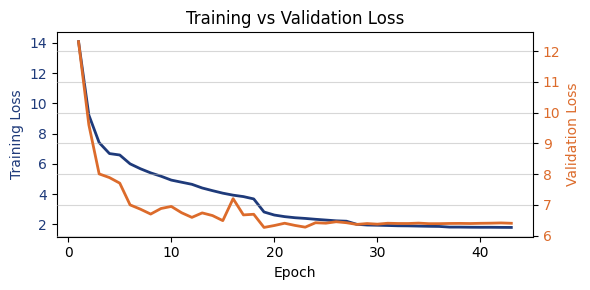

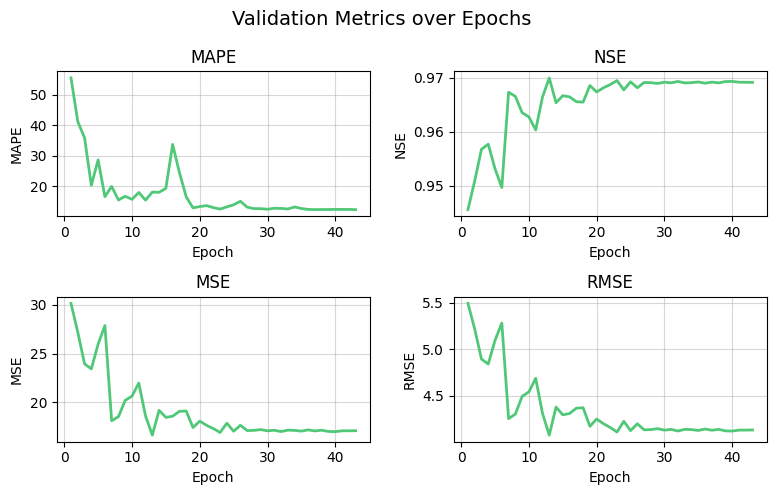

In [ ]:
# Path to your output.log file
log_path = Path(f"{run_dir}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path, verbose=False)

plot_training_curves(train_df, val_df)
plot_validation_metrics(val_df)


---

Code for 24h predictions:

In [5]:

results_ = results[basin]["1h"]["xr"]
scores = dict_without_xr_key(results[basin]['1h'])

# store only the values in numpy arrays from xarray DataArrays
y_true = results_['streamflow_obs']#.values
y_pred = results_['streamflow_sim']#.values

verb = False
if verb: 
    print("\n-- Calculating MAPE values for each horizon: --\n")
    mapes = mape_array(y_true, y_pred, verbose=verb)
    print("\n-- MAPE calculation per horizon completed. --\n")
else:
    mapes = mape_array(y_true, y_pred, verbose=verb)



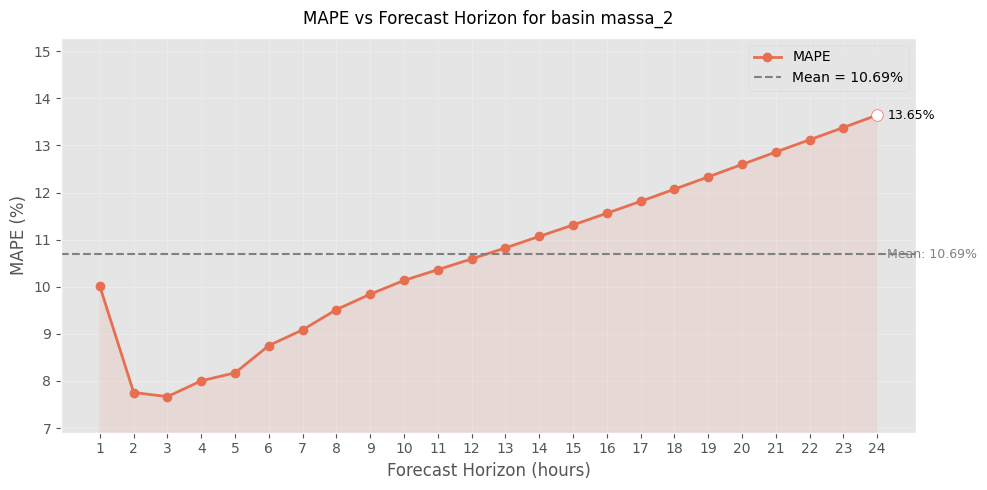

In [6]:
# Example usage (variables `mapes`, `horizons`, and `basin` exist in the notebook):
plot_mape_horizon(
    mapes,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}"
)


In [ ]:

scores_str = str.join(', ', [f"{key} : {scores[key]:.2f}" for key in scores])
title24 = f"Massa – {cfg.predict_last_n}h | " + scores_str
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[1, 6, cfg.predict_last_n])
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[cfg.predict_last_n])


In [8]:
# Example: visualize forecast issued on April 10, 2024, at midnight
plot_forecast_horizon_24h(
    issue_date="2024-08-10 00:00:00",
    xr_ds=results_
).show()
plot_forecast_horizon_24h(
    issue_date="2024-08-10 01:00:00",
    xr_ds=results_
).show()

In [9]:
plot_forecast_horizon_series(
    issue_date="2024-06-10 00:00:00",
    xr_ds=results_,
    n_forecasts=10
).show()

---

## Computation of all metric scores
Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [10]:
qobs=results_['streamflow_obs']
qsim=results_['streamflow_sim']
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))

for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.939
MSE: 38.485
RMSE: 6.204
KGE: 0.887
Alpha-NSE: 0.913
Beta-KGE: 0.934
Beta-NSE: -0.051
Pearson-r: 0.972
FHV: -6.771
FMS: -3.402
FLV: -24.358
Peak-Timing: nan
Peak-MAPE: 23.967
MAPE: 13.647


In [11]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=6), qsim.isel(time_step=6))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.975
MSE: 15.320
RMSE: 3.914
KGE: 0.944
Alpha-NSE: 0.955
Beta-KGE: 0.967
Beta-NSE: -0.025
Pearson-r: 0.989
FHV: -3.263
FMS: -1.954
FLV: -31.522
Peak-Timing: nan
Peak-MAPE: 15.335
MAPE: 9.086
